In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from useful_functions import *
import pandas as pd
from joblib import Parallel, delayed

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
color_data      = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_with_Flux.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [ ]:
parent_samples_ids  = read_ids('./samples_ids/parent_samples_ids.txt')
double_sample_ids   = read_ids('./samples_ids/dp_samples_ids.txt')
single_sample_ids = [item for item in parent_samples_ids if item not in double_sample_ids]

print(len(parent_samples_ids))
print(len(double_sample_ids))
print(len(single_sample_ids))

61905
21537
40380


In [ ]:
with open('./samples_ids/cs_samples_ids.txt', "w+") as f:
    for tid in single_sample_ids:
        f.write(f"{tid}\n")

In [5]:
DP_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=double_sample_ids)
CS_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=single_sample_ids)

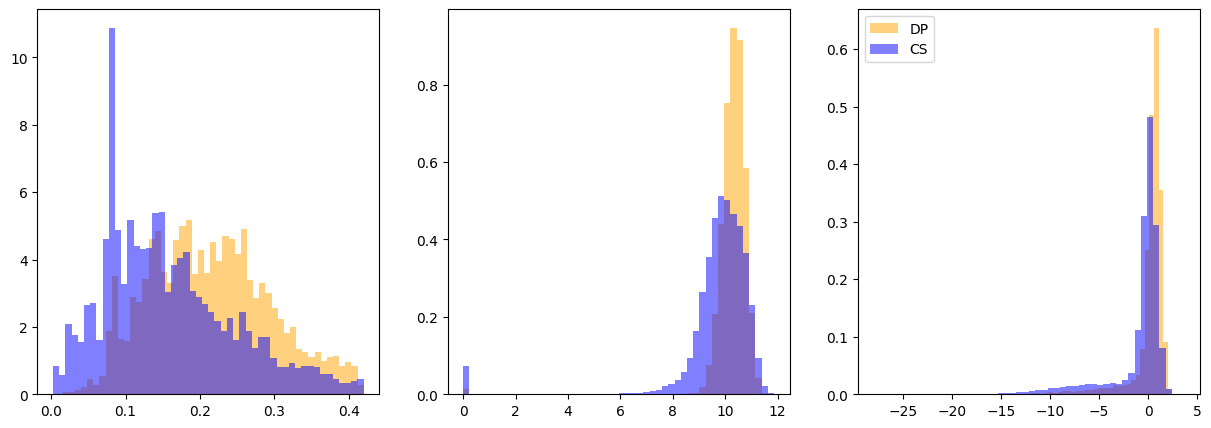

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].hist(DP_SPECTRA.df['z'], bins=50, alpha=0.5, label='DP', density=True, color='orange')
ax[0].hist(CS_SPECTRA.df['z'], bins=50, alpha=0.5, label='CS', density=True, color='blue')

ax[1].hist(DP_SPECTRA.df['LOGM'], bins=50, alpha=0.5, label='DP', density=True, color='orange')
ax[1].hist(CS_SPECTRA.df['LOGM'], bins=50, alpha=0.5, label='CS', density=True, color='blue')

ax[2].hist(DP_SPECTRA.df['LOGSFR'], bins=50, alpha=0.5, label='DP', density=True, color='orange')
ax[2].hist(CS_SPECTRA.df['LOGSFR'], bins=50, alpha=0.5, label='CS', density=True, color='blue')

plt.legend()
plt.show()


Original CS sample size: 40380
Matched CS sample size: 20833


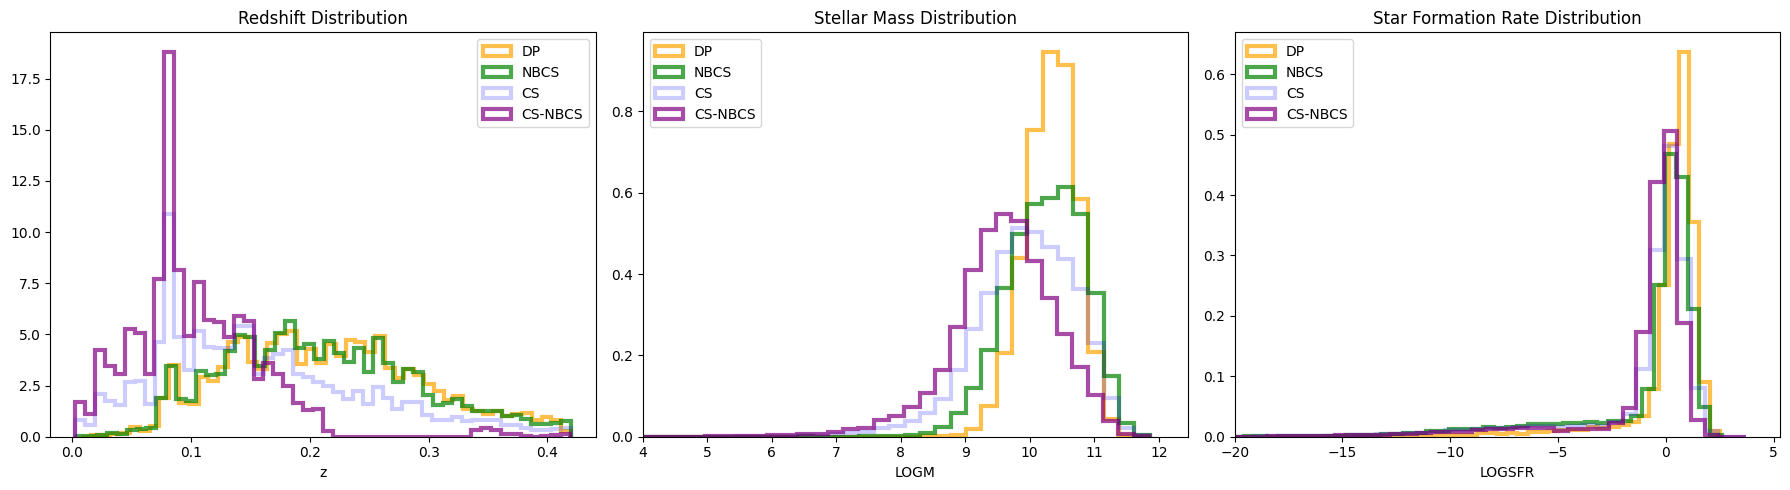

In [7]:
# Define the number of bins for redshift
z_bins = np.linspace(DP_SPECTRA.df['z'].min(), DP_SPECTRA.df['z'].max(), 21)

# Calculate the 1D histogram for the DP (target) sample
H_dp, _ = np.histogram(DP_SPECTRA.df['z'], bins=z_bins)

# Calculate the 1D histogram for the CS (parent) sample
H_cs, _ = np.histogram(CS_SPECTRA.df['z'], bins=z_bins)

# Avoid division by zero by replacing zeros in H_cs with a large number (or np.inf)
H_cs_safe = np.where(H_cs == 0, np.inf, H_cs)

# Calculate the sampling ratio for each bin
# We want to match the DP distribution, so the ratio is H_dp / H_cs
# We cap the ratio at 1, as we cannot sample more than what is available
sampling_ratio = np.minimum(H_dp / H_cs_safe, 1.0)

# Find which bin each galaxy in the CS sample belongs to
z_bin_indices = np.digitize(CS_SPECTRA.df['z'], bins=z_bins) - 1

# Ensure indices are within the valid range [0, n_bins-1]
z_bin_indices = np.clip(z_bin_indices, 0, len(z_bins) - 2)

# Get the sampling probability for each galaxy in the CS sample
p = sampling_ratio[z_bin_indices]

# Decide which galaxies to keep based on the calculated probability
keep_mask = np.random.rand(len(CS_SPECTRA.df)) < p
matched_cs_indices = CS_SPECTRA.df.index[keep_mask]
unmatched_cs_indices = CS_SPECTRA.df.index[~keep_mask]
# Create a new DataFrame for the matched control sample
matched_cs_df = CS_SPECTRA.df.loc[matched_cs_indices]
unmatched_cs_df = CS_SPECTRA.df.loc[unmatched_cs_indices]
print(f"Original CS sample size: {len(CS_SPECTRA.df)}")
print(f"Matched CS sample size: {len(matched_cs_df)}")

# Plot the distributions to verify the matching
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

# Plot z distribution
axes[0].hist(DP_SPECTRA.df['z'], bins=50, alpha=0.7, label='DP', density=True, color='orange', histtype='step', linewidth=3)
axes[0].hist(matched_cs_df['z'], bins=50, alpha=0.7, label='NBCS', density=True, color='green', histtype='step', linewidth=3)
axes[0].hist(CS_SPECTRA.df['z'], bins=50, alpha=0.2, label='CS', density=True, color='blue', histtype='step', linewidth=3)
axes[0].hist(unmatched_cs_df['z'], bins=50, alpha=0.7, label='CS-NBCS', density=True, color='purple', histtype='step', linewidth=3)
axes[0].set_title('Redshift Distribution')
axes[0].set_xlabel('z')
axes[0].legend()

# Plot LOGM distribution
axes[1].hist(DP_SPECTRA.df['LOGM'], bins=50, alpha=0.7, label='DP', density=True, color='orange', histtype='step', linewidth=3)
axes[1].hist(matched_cs_df['LOGM'], bins=50, alpha=0.7, label='NBCS', density=True, color='green', histtype='step', linewidth=3)
axes[1].hist(CS_SPECTRA.df['LOGM'], bins=50, alpha=0.2, label='CS', density=True, color='blue', histtype='step', linewidth=3)
axes[1].hist(unmatched_cs_df['LOGM'], bins=50, alpha=0.7, label='CS-NBCS', density=True, color='purple', histtype='step', linewidth=3)
axes[1].set_title('Stellar Mass Distribution')
axes[1].set_xlabel('LOGM')
axes[1].set_xlim(left=4)
axes[1].legend()

axes[2].hist(DP_SPECTRA.df['LOGSFR'], bins=50, alpha=0.7, label='DP', density=True, color='orange', histtype='step', linewidth=3)
axes[2].hist(matched_cs_df['LOGSFR'], bins=50, alpha=0.7, label='NBCS', density=True, color='green', histtype='step', linewidth=3)
axes[2].hist(CS_SPECTRA.df['LOGSFR'], bins=50, alpha=0.2, label='CS', density=True, color='blue', histtype='step', linewidth=3)
axes[2].hist(unmatched_cs_df['LOGSFR'], bins=50, alpha=0.7, label='CS-NBCS', density=True, color='purple', histtype='step', linewidth=3)
axes[2].set_title('Star Formation Rate Distribution')
axes[2].set_xlabel('LOGSFR')
axes[2].set_xlim(left=-20)
axes[2].legend()

plt.tight_layout()
plt.savefig('./figures/Jan7/dp_nbcs_cs_comparison.png')
plt.show()


In [ ]:
with open("./samples_ids/nbcs_samples_ids.txt", "w+") as f:
    for tid in matched_cs_df['TARGETID'].to_list():
        f.write(f"{tid}\n")